<a href="https://colab.research.google.com/github/ncshin/intro-ml-course-winter2026/blob/main/Datathon%20%234.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
from google.colab import drive

In [ ]:
import pandas as pd
import numpy as np
import warnings
import os
import seaborn as sns
import scipy.stats as stats
import matplotlib.pyplot as plt

# Import ML Libraries
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, roc_curve

In [ ]:
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df = pd.read_csv("/content/drive/My Drive/Datathon #4 - mhealth Dataset - HAD7001.csv")

In [ ]:
df.isnull().sum()
# no missing data

,0
alx,0
aly,0
alz,0
glx,0
gly,0
glz,0
arx,0
ary,0
arz,0
grx,0


# Pre-Processing


In [ ]:
# This is just copying what Konrad did in the tutorial, takes a minute to run

def Create_ID_column_for_participant_and_activity(df, participant_ID:str, activity:str, count_col='activity_participant_ID'):
    df[count_col] = 0  # initialize the new ID column with 0

    # initialize variables to store last values
    last_subject = None
    last_activity = None
    count = 0

    # loop through the rows of the df
    for index, row in df.iterrows():
        current_subject = row[participant_ID]
        current_activity = row[activity]

        # check if the values are the same as the last row
        if current_subject == last_subject and current_activity == last_activity:
            df.at[index, count_col] = count
        else:
            count += 1
            df.at[index, count_col] = count

        # update the last values
        last_subject = current_subject
        last_activity = current_activity

    return df

df = Create_ID_column_for_participant_and_activity(
    df,
    participant_ID='subject',
    activity='Activity'
)

# Visualize groups (by subject and activity)
heatmap_data = df.groupby(['Activity', 'subject'])['activity_participant_ID'].nunique().unstack()

# Plot heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_data, annot=True, fmt='g', cmap='YlGnBu', cbar_kws={'label': 'Count'})
plt.title('Unique Groups of Sequences for Each Activity Category and Subject (Grouped: each time someone switches activity)')
plt.xlabel('Subject')
plt.ylabel('Activity Category')
plt.show

KeyboardInterrupt: 

In [ ]:
# We remove Subject 9 for not enough data

df = df[df['subject'] != 'subject9']

In [ ]:
# Creating separate dataframes for each subject
# Subjects 7 and 8 will be our test data, so I am not touching them in pre-processing

Train_Subject1 = df[df['subject'] == 'subject1']
Train_Subject2 = df[df['subject'] == 'subject2']
Train_Subject3 = df[df['subject'] == 'subject3']
Train_Subject4 = df[df['subject'] == 'subject4']
Train_Subject5 = df[df['subject'] == 'subject5']
Train_Subject6 = df[df['subject'] == 'subject6']
Test_Subject7 = df[df['subject'] == 'subject7']
Test_Subject8 = df[df['subject'] == 'subject8']

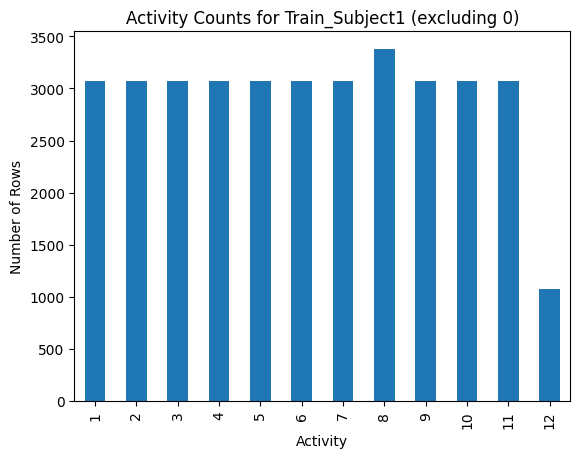

In [ ]:
# Massive class imbalance, confirmed that we can ignore rows with activity=0

# Train_Subject1['Activity'].value_counts().sort_index().plot(kind='bar')

filtered1 = Train_Subject1[Train_Subject1['Activity'] != 0]
filtered1['Activity'].value_counts().sort_index().plot(kind='bar')

plt.xlabel('Activity')
plt.ylabel('Number of Rows')
plt.title('Activity Counts for Train_Subject1 (excluding 0)')
plt.show()

In [ ]:
filtered2 = Train_Subject2[Train_Subject2['Activity'] != 0]
filtered3 = Train_Subject3[Train_Subject3['Activity'] != 0]
filtered4 = Train_Subject4[Train_Subject4['Activity'] != 0]
filtered5 = Train_Subject5[Train_Subject5['Activity'] != 0]
filtered6 = Train_Subject6[Train_Subject6['Activity'] != 0]

In [ ]:
# identify where the activity changes
groups1 = (Train_Subject1['Activity'] != Train_Subject1['Activity'].shift()).cumsum()
# count rows in each consecutive segment
activity_1 = Train_Subject1.groupby(groups1)['Activity'].agg(['first', 'size'])
activity_1 = activity_1.rename(columns={'first': 'Subject1_activity'})
print(activity_1)

groups2 = (Train_Subject2['Activity'] != Train_Subject2['Activity'].shift()).cumsum()
activity_2 = Train_Subject2.groupby(groups2)['Activity'].agg(['first', 'size'])
activity_2 = activity_2.rename(columns={'first': 'Subject2_activity'})

groups3 = (Train_Subject3['Activity'] != Train_Subject3['Activity'].shift()).cumsum()
activity_3 = Train_Subject3.groupby(groups3)['Activity'].agg(['first', 'size'])
activity_3 = activity_3.rename(columns={'first': 'Subject3_activity'})

groups4 = (Train_Subject4['Activity'] != Train_Subject4['Activity'].shift()).cumsum()
activity_4 = Train_Subject4.groupby(groups4)['Activity'].agg(['first', 'size'])
activity_4 = activity_4.rename(columns={'first': 'Subject4_activity'})

groups5 = (Train_Subject5['Activity'] != Train_Subject5['Activity'].shift()).cumsum()
activity_5 = Train_Subject5.groupby(groups5)['Activity'].agg(['first', 'size'])
activity_5 = activity_5.rename(columns={'first': 'Subject5_activity'})

groups6 = (Train_Subject6['Activity'] != Train_Subject6['Activity'].shift()).cumsum()
activity_6 = Train_Subject6.groupby(groups6)['Activity'].agg(['first', 'size'])
activity_6 = activity_6.rename(columns={'first': 'Subject6_activity'})

groups7 = (Test_Subject7['Activity'] != Test_Subject7['Activity'].shift()).cumsum()
activity_7 = Test_Subject7.groupby(groups7)['Activity'].agg(['first', 'size'])
activity_7 = activity_7.rename(columns={'first': 'Subject7_activity'})

groups8 = (Test_Subject8['Activity'] != Test_Subject8['Activity'].shift()).cumsum()
activity_8 = Test_Subject8.groupby(groups8)['Activity'].agg(['first', 'size'])
activity_8 = activity_8.rename(columns={'first': 'Subject7_activity'})

          Subject1_activity   size
Activity                          
1                         0   6656
2                         1   3072
3                         0   3072
4                         2   3072
5                         0   3072
6                         3   3072
7                         0   6144
8                         4   3072
9                         0   6144
10                        6   3072
11                        0  12288
12                        7   3072
13                        0   5632
14                        8   3379
15                        0  11264
16                        9   3072
17                        0   8909
18                       10   3072
19                        0   7680
20                       11   3072
21                        0  11520
22                       12   1075
23                        0  42701
24                        5   3072
25                        0   1024


In [ ]:
# This table is showing the sequence of activities each subject engaged in
# ex. Subject 1 did activity 0 for 6656 rows (6656/50Hz = 133.12 seconds), then activity 1 for 3072/50Hz = 61.44 seconds, then back to activity 0 for 3072/50Hz = 61.44 seconds, etc.

activity_all = pd.concat(
    [activity_1, activity_2, activity_3,
     activity_4, activity_5, activity_6],
    axis=1
).reset_index(drop=True)
activity_all

,Subject1_activity,size,Subject2_activity,size,Subject3_activity,size,Subject4_activity,size,Subject5_activity,size,Subject6_activity,size
0,0,6656,0,14592,0,4608,0,2304,0,3072,0,3072
1,1,3072,5,3072,1,3072,5,3072,1,3072,1,3072
2,0,3072,0,26112,0,2560,0,34816,0,1536,0,1536
3,2,3072,1,3072,2,3072,1,3072,2,3072,2,3072
4,0,3072,0,3072,0,3072,0,2304,0,1536,0,1536
5,3,3072,2,3072,3,3072,2,3072,3,3072,3,3072
6,0,6144,0,3072,0,5120,0,2048,0,1536,0,1536
7,4,3072,3,3072,4,3072,3,3072,4,3072,4,3072
8,0,6144,0,3328,0,7782,0,3584,0,4608,0,4710
9,6,3072,4,3072,6,3226,4,3072,6,2765,6,2202


In [ ]:
# Same as above, just deleted all instances where activity=0
activity_non0 = activity_all.iloc[1::2].reset_index(drop=True)
activity_non0
# Konrad said chunks of 256 (~5 seconds) is appropriate, especially if using LSTM


,Subject1_activity,size,Subject2_activity,size,Subject3_activity,size,Subject4_activity,size,Subject5_activity,size,Subject6_activity,size
0,1,3072,5,3072,1,3072,5,3072,1,3072,1,3072
1,2,3072,1,3072,2,3072,1,3072,2,3072,2,3072
2,3,3072,2,3072,3,3072,2,3072,3,3072,3,3072
3,4,3072,3,3072,4,3072,3,3072,4,3072,4,3072
4,6,3072,4,3072,6,3226,4,3072,6,2765,6,2202
5,7,3072,6,3174,7,3379,6,3328,7,2868,7,2099
6,8,3379,7,3328,8,3175,7,3277,8,2714,8,2304
7,9,3072,8,3430,9,3072,8,3123,9,3072,9,3072
8,10,3072,10,3072,10,3072,9,3072,10,3072,10,3072
9,11,3072,11,3072,11,3072,10,3072,11,3072,11,3072


In [ ]:
# select all columns named 'size'
size_cols = activity_non0.filter(regex='^size')

# compute remainders after dividing by 256
remainders = size_cols % 256

remainders = activity_non0.filter(regex='^size').mod(256)

remainders

,size,size,size,size,size,size
0,0,0,0,0,0,0
1,0,0,0,0,0,0
2,0,0,0,0,0,0
3,0,0,0,0,0,0
4,0,0,154,0,205,154
5,0,102,51,0,52,51
6,51,0,103,205,154,0
7,0,102,0,51,0,0
8,0,0,0,0,0,0
9,0,0,0,0,0,0


In [ ]:
# 3 dimensions: number of chunks, sequence length, number of features
# total number of samples across all subjects, 256, 12
# NOTE to Amir: hidden size of the LSTM = 12

# X_train is a 3-dimensional matrix, y_train is a one-dimensional matrix wth just the outputs that correspond to each element in the first dimension in X_train
# X_pred and Y_pred

In [ ]:
filtered1

,alx,aly,alz,glx,gly,glz,arx,ary,arz,grx,gry,grz,Activity,subject,activity_participant_ID
6656,2.6493,-9.4517,0.37683,-0.20965,-0.88931,-0.508840,-2.8439,-9.0618,1.81770,-0.058824,-0.93429,-0.34483,1,subject1,2
6657,2.4157,-9.5306,0.40179,-0.20965,-0.88931,-0.508840,-2.9935,-9.2048,1.51890,-0.058824,-0.93429,-0.34483,1,subject1,2
6658,2.3865,-9.5991,0.48141,-0.20037,-0.86867,-0.506880,-2.8846,-9.1945,1.55070,-0.058824,-0.93429,-0.34483,1,subject1,2
6659,2.3758,-9.5997,0.42919,-0.20037,-0.86867,-0.506880,-2.9245,-9.1746,1.54130,-0.078431,-0.93429,-0.34052,1,subject1,2
6660,2.3239,-9.5406,0.40038,-0.20037,-0.86867,-0.506880,-2.8963,-9.2039,1.61270,-0.078431,-0.93429,-0.34052,1,subject1,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
160251,-1.1274,-7.2045,-3.62150,-1.40260,-1.24200,-0.056974,-2.3478,-9.4027,-1.27220,-1.102000,-0.47433,-0.38362,5,subject1,24
160252,-1.3928,-5.8547,-3.29620,-1.40260,-1.24200,-0.056974,-1.9978,-9.4592,-0.92088,-1.102000,-0.47433,-0.38362,5,subject1,24
160253,-1.1938,-5.8499,-3.80440,-1.42490,-1.12760,-0.290770,-1.9755,-8.8985,-0.85118,-1.102000,-0.47433,-0.38362,5,subject1,24
160254,-1.9781,-6.1079,-1.87730,-1.42490,-1.12760,-0.290770,-2.2332,-8.8793,-0.93355,-1.102000,-0.47433,-0.38362,5,subject1,24


In [ ]:
chunk_size = 256

# identify consecutive blocks where Activity stays the same
g1 = (filtered1['Activity'] != filtered1['Activity'].shift()).cumsum()

# keep only full 256-row chunks within each consecutive activity block
filtered_chunks1 = (
    filtered1.groupby(g1, group_keys=False)
    .apply(lambda x: x.iloc[: (len(x) // chunk_size) * chunk_size])
    .reset_index(drop=True)
)

In [ ]:
summary = filtered1.groupby(g1).size().to_frame('original_size')
summary['kept'] = (summary['original_size'] // 256) * 256
summary['dropped'] = summary['original_size'] - summary['kept']
print(summary)

          original_size  kept  dropped
Activity                              
1                  3072  3072        0
2                  3072  3072        0
3                  3072  3072        0
4                  3072  3072        0
5                  3072  3072        0
6                  3072  3072        0
7                  3379  3328       51
8                  3072  3072        0
9                  3072  3072        0
10                 3072  3072        0
11                 1075  1024       51
12                 3072  3072        0


In [ ]:
g2 = (filtered2['Activity'] != filtered2['Activity'].shift()).cumsum()
filtered_chunks2 = (
    filtered2.groupby(g2, group_keys=False)
    .apply(lambda x: x.iloc[: (len(x) // chunk_size) * chunk_size])
    .reset_index(drop=True)
)

g3 = (filtered3['Activity'] != filtered3['Activity'].shift()).cumsum()
filtered_chunks3 = (
    filtered3.groupby(g3, group_keys=False)
    .apply(lambda x: x.iloc[: (len(x) // chunk_size) * chunk_size])
    .reset_index(drop=True)
)

g4 = (filtered4['Activity'] != filtered4['Activity'].shift()).cumsum()
filtered_chunks4 = (
    filtered4.groupby(g4, group_keys=False)
    .apply(lambda x: x.iloc[: (len(x) // chunk_size) * chunk_size])
    .reset_index(drop=True)
)

g5 = (filtered5['Activity'] != filtered5['Activity'].shift()).cumsum()
filtered_chunks5 = (
    filtered5.groupby(g5, group_keys=False)
    .apply(lambda x: x.iloc[: (len(x) // chunk_size) * chunk_size])
    .reset_index(drop=True)
)

g6 = (filtered6['Activity'] != filtered6['Activity'].shift()).cumsum()
filtered_chunks6 = (
    filtered6.groupby(g6, group_keys=False)
    .apply(lambda x: x.iloc[: (len(x) // chunk_size) * chunk_size])
    .reset_index(drop=True)
)

In [ ]:
filtered_chunks_all = pd.concat([
    filtered_chunks1,
    filtered_chunks2,
    filtered_chunks3,
    filtered_chunks4,
    filtered_chunks5,
    filtered_chunks6
], ignore_index=True)

In [ ]:
# Sanity check, they're equivalent
print(len(filtered_chunks_all)/256)
y_train = filtered_chunks_all['Activity'].iloc[::256].reset_index(drop=True)
print(len(y_train))

805.0
805


In [ ]:
X = filtered_chunks_all.drop(columns=['Activity', 'subject', 'activity_participant_ID'])
X_train = X.to_numpy().reshape(-1, 256, X.shape[1])
print(X_train.shape)
print(y_train.shape)

(805, 256, 12)
(805,)


In [ ]:
# Testing sequences
# Filter out Activity=0 for test subjects
filtered7 = Test_Subject7[Test_Subject7['Activity'] != 0]
filtered8 = Test_Subject8[Test_Subject8['Activity'] != 0]

chunk_size = 256  # Window size

# Identify consecutive activity blocks and keep full windows only
g7 = (filtered7['Activity'] != filtered7['Activity'].shift()).cumsum()
filtered_chunks7 = (
    filtered7.groupby(g7, group_keys=False)
    .apply(lambda x: x.iloc[: (len(x) // chunk_size) * chunk_size])
    .reset_index(drop=True)
)

g8 = (filtered8['Activity'] != filtered8['Activity'].shift()).cumsum()
filtered_chunks8 = (
    filtered8.groupby(g8, group_keys=False)
    .apply(lambda x: x.iloc[: (len(x) // chunk_size) * chunk_size])
    .reset_index(drop=True)
)

# Combine test chunks
filtered_chunks_test = pd.concat([filtered_chunks7, filtered_chunks8], ignore_index=True)

# Extract labels for each window
y_test = filtered_chunks_test['Activity'].iloc[::chunk_size].reset_index(drop=True)

# Extract features and reshape into 3D array (samples, timesteps, features)
X_test = filtered_chunks_test.drop(columns=['Activity', 'subject', 'activity_participant_ID'])
X_test = X_test.to_numpy().reshape(-1, chunk_size, X_test.shape[1])

# Sanity check
print(X_test.shape)
print(y_test.shape)

(262, 256, 12)
(262,)


# Model development (LSTM)

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from torch.optim import Adam
from tqdm import tqdm, trange
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [ ]:
y_train = y_train - 1
y_test = y_test - 1

X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

train_dataset = TensorDataset(torch.tensor(X_train).float(), torch.tensor(y_train.to_numpy()))
val_dataset = TensorDataset(torch.tensor(X_val).float(), torch.tensor(y_val.to_numpy()))
test_dataset = TensorDataset(torch.tensor(X_test).float(), torch.tensor(y_test.to_numpy()))

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [ ]:
class LSTMClassifier(nn.Module):
    def __init__(self, input_size=12, hidden_size=12, num_classes=12, dropout=0.0):
        super(LSTMClassifier, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = 1
        self.lstm = nn.LSTM(input_size, hidden_size, self.num_layers, batch_first=True, dropout=dropout)

        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)

        out, (hn, cn) = self.lstm(x, (h0, c0))
        last_timestep_output = out[:, -1, :]

        out = self.fc(last_timestep_output)
        return out

In [ ]:
lstm = LSTMClassifier()
x = torch.randn(32, 256, 12)
lstm(x).shape

torch.Size([32, 12])

In [ ]:
class_count = [len(y_train[y_train == t]) for t in sorted(y_train.unique())]
class_weight = 1 / torch.tensor(class_count, dtype=torch.float)
class_weight

tensor([0.0161, 0.0154, 0.0169, 0.0164, 0.0164, 0.0222, 0.0200, 0.0182, 0.0175,
        0.0172, 0.0185, 0.0588])

In [ ]:
optimizer = Adam(lstm.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss(weight=class_weight.to(device))

In [ ]:
def train_model(model, data_loader, optimizer, criterion, epoch_num):
  model.train()
  total_loss = 0
  count = 0

  with tqdm(enumerate(data_loader), total=len(data_loader)) as p:
    for i, (x, y) in p:
      x = x.to(device)
      y = y.to(device)
      optimizer.zero_grad()
      output = model(x)
      loss = criterion(output, y)
      loss.backward()
      optimizer.step()
      total_loss += loss.item()
      count += len(y)
  print(f'Epoch: {epoch_num}, Average Loss: {total_loss / count}')
  return total_loss / count

def test_model(model, data_loader, criterion, epoch_num):
  model.eval()
  total_loss = 0
  count = 0
  y_true = []
  y_pred = []

  with torch.no_grad():
    with tqdm(enumerate(data_loader), total=len(data_loader)) as p:
      for i, (x, y) in p:
        x = x.to(device)
        y = y.to(device)
        output = model(x)
        loss = criterion(output, y)
        total_loss += loss.item()
        count += len(y)
        y_true.extend(y.cpu().numpy())
        y_pred.extend(output.argmax(dim=1).cpu().numpy())

  acc = accuracy_score(y_true, y_pred)
  prec = precision_score(y_true, y_pred, average='macro')
  rec = recall_score(y_true, y_pred, average='macro')
  f1 = f1_score(y_true, y_pred, average='macro')
  # auc = roc_auc_score(y_true, y_pred)
  print(f'Epoch {epoch_num}, Average Loss: {total_loss / count}, Accuracy: {acc}, Precision: {prec}, Recall: {rec}, F1: {f1}')
  return total_loss / count, [acc, prec, rec, f1]

In [ ]:
num_epochs = 400
all_train_loss = []
all_val_loss = []


min_loss = float('inf')
best_model_loss = None
for epoch in range(num_epochs):
  train_loss = train_model(lstm, train_loader, optimizer, criterion, epoch + 1)
  val_loss, [val_acc, val_prec, val_recall, val_f1] = test_model(lstm, val_loader, criterion, epoch + 1)

  if val_loss < min_loss:
    min_loss = val_loss
    best_model_loss = lstm.state_dict()

  all_train_loss.append(train_loss)
  all_val_loss.append(val_loss)

100%|██████████| 21/21 [00:01<00:00, 13.13it/s]


Epoch: 1, Average Loss: 0.08018465478968176


100%|██████████| 6/6 [00:00<00:00, 34.36it/s]
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Epoch 1, Average Loss: 0.08936092572182602, Accuracy: 0.13043478260869565, Precision: 0.1303483639587363, Recall: 0.12056277056277054, F1: 0.07407407407407407


100%|██████████| 21/21 [00:01<00:00, 17.34it/s]


...

Epoch 399, Average Loss: 0.007544897057069754, Accuracy: 0.9503105590062112, Precision: 0.9471044478397421, Recall: 0.9525613275613277, F1: 0.9492068134752607


100%|██████████| 21/21 [00:00<00:00, 33.83it/s]


Epoch: 400, Average Loss: 0.000839862512621265


100%|██████████| 6/6 [00:00<00:00, 72.16it/s]

Epoch 400, Average Loss: 0.007510808694193729, Accuracy: 0.9503105590062112, Precision: 0.9471044478397421, Recall: 0.9525613275613277, F1: 0.9492068134752607


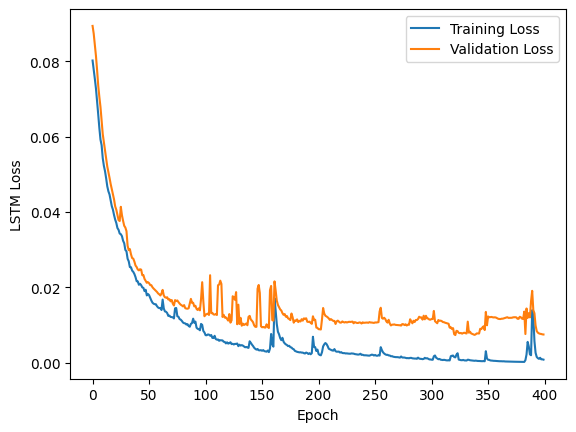

In [ ]:
plt.plot(all_train_loss, label='Training Loss')
plt.plot(all_val_loss, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('LSTM Loss')
plt.legend()
plt.show()

In [ ]:
lstm.load_state_dict(best_model_loss)
_, _ = test_model(lstm, test_loader, criterion, 0)

100%|██████████| 9/9 [00:00<00:00, 85.90it/s]

Epoch 0, Average Loss: 0.041730185672072054, Accuracy: 0.7595419847328244, Precision: 0.7933356676003736, Recall: 0.752281746031746, F1: 0.7410663356972816


# Model development (RNN)

In [ ]:
class RNNClassifier(nn.Module):
    def __init__(self, input_size=12, hidden_size=12, num_classes=12, dropout=0.0):
        super(RNNClassifier, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = 1
        self.rnn = nn.RNN(input_size, hidden_size, self.num_layers, batch_first=True, dropout=dropout)

        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)

        out, hn = self.rnn(x, h0)
        last_timestep_output = out[:, -1, :]

        out = self.fc(last_timestep_output)
        return out

In [ ]:
rnn = RNNClassifier()
x = torch.randn(32, 256, 12)
rnn(x).shape

torch.Size([32, 12])

In [ ]:
optimizer = Adam(rnn.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss(weight=class_weight.to(device))

In [ ]:
num_epochs = 400
all_train_loss = []
all_val_loss = []


min_loss = float('inf')
best_model_loss = None
for epoch in range(num_epochs):
  train_loss = train_model(rnn, train_loader, optimizer, criterion, epoch + 1)
  val_loss, [val_acc, val_prec, val_recall, val_f1] = test_model(rnn, val_loader, criterion, epoch + 1)

  if val_loss < min_loss:
    min_loss = val_loss
    best_model_loss = rnn.state_dict()

  all_train_loss.append(train_loss)
  all_val_loss.append(val_loss)

100%|██████████| 21/21 [00:00<00:00, 25.09it/s]


Epoch: 1, Average Loss: 0.08295663321240349


100%|██████████| 6/6 [00:00<00:00, 115.40it/s]
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Epoch 1, Average Loss: 0.0936557358096105, Accuracy: 0.07453416149068323, Precision: 0.07018518518518518, Recall: 0.08910217462849042, F1: 0.03962079264404846


100%|██████████| 21/21 [00:00<00:00, 23.35it/s]


...

Epoch 399, Average Loss: 0.040219065195285016, Accuracy: 0.6273291925465838, Precision: 0.6112685560053982, Recall: 0.6164204703678389, F1: 0.5948165763537425


100%|██████████| 21/21 [00:00<00:00, 23.95it/s]


Epoch: 400, Average Loss: 0.024244383717916027


100%|██████████| 6/6 [00:00<00:00, 141.86it/s]

Epoch 400, Average Loss: 0.04018861036863386, Accuracy: 0.6211180124223602, Precision: 0.6035279170147593, Recall: 0.6126325915799601, F1: 0.58781796821383


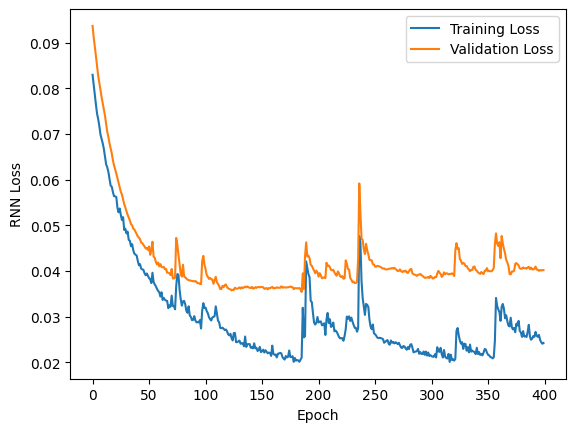

In [ ]:
plt.plot(all_train_loss, label='Training Loss')
plt.plot(all_val_loss, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('RNN Loss')
plt.legend()
plt.show()

In [ ]:
rnn.load_state_dict(best_model_loss)
_, _ = test_model(rnn, test_loader, criterion, 0)

100%|██████████| 9/9 [00:00<00:00, 207.38it/s]

Epoch 0, Average Loss: 0.0874615534571291, Accuracy: 0.31297709923664124, Precision: 0.33959098386181724, Recall: 0.30079365079365084, F1: 0.30218633795918254


# Model development (GRU)

In [ ]:
class GRUClassifier(nn.Module):
    def __init__(self, input_size=12, hidden_size=12, num_classes=12, dropout=0.0):
        super(GRUClassifier, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = 1
        self.gru = nn.GRU(input_size, hidden_size, self.num_layers, batch_first=True, dropout=dropout)

        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)

        out, hn = self.gru(x, h0)
        last_timestep_output = out[:, -1, :]

        out = self.fc(last_timestep_output)
        return out

In [ ]:
gru = GRUClassifier()
x = torch.randn(32, 256, 12)
gru(x).shape

torch.Size([32, 12])

In [ ]:
optimizer = Adam(gru.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss(weight=class_weight.to(device))

In [ ]:
num_epochs = 400
all_train_loss = []
all_val_loss = []


min_loss = float('inf')
best_model_loss = None
for epoch in range(num_epochs):
  train_loss = train_model(gru, train_loader, optimizer, criterion, epoch + 1)
  val_loss, [val_acc, val_prec, val_recall, val_f1] = test_model(gru, val_loader, criterion, epoch + 1)

  if val_loss < min_loss:
    min_loss = val_loss
    best_model_loss = gru.state_dict()

  all_train_loss.append(train_loss)
  all_val_loss.append(val_loss)

100%|██████████| 21/21 [00:02<00:00,  9.48it/s]


Epoch: 1, Average Loss: 0.08493781645105493


100%|██████████| 6/6 [00:00<00:00, 51.05it/s]
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Epoch 1, Average Loss: 0.09048204096207707, Accuracy: 0.055900621118012424, Precision: 0.0765542328042328, Recall: 0.06979253689780006, F1: 0.07204732204732205


100%|██████████| 21/21 [00:02<00:00,  9.02it/s]


...

Epoch 399, Average Loss: 0.0073318184636857195, Accuracy: 0.937888198757764, Precision: 0.9226764828738513, Recall: 0.9185305435305436, F1: 0.9186344512937031


100%|██████████| 21/21 [00:02<00:00,  9.86it/s]


Epoch: 400, Average Loss: 0.00034499246271338705


100%|██████████| 6/6 [00:00<00:00, 62.78it/s]

Epoch 400, Average Loss: 0.007498822205697088, Accuracy: 0.9316770186335404, Precision: 0.917824074074074, Recall: 0.913900913900914, F1: 0.9138741491196077


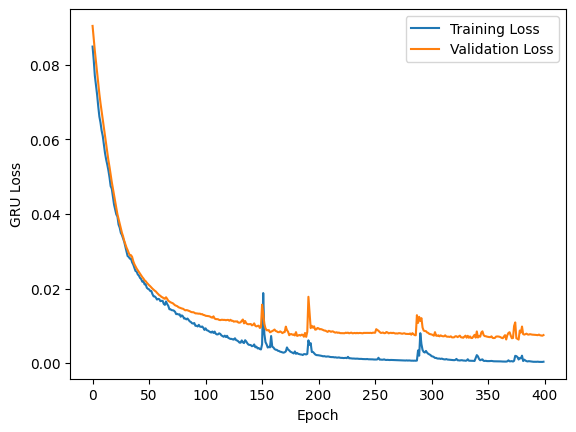

In [ ]:
plt.plot(all_train_loss, label='Training Loss')
plt.plot(all_val_loss, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('GRU Loss')
plt.legend()
plt.show()

In [ ]:
gru.load_state_dict(best_model_loss)
_, _ = test_model(gru, test_loader, criterion, 0)

100%|██████████| 9/9 [00:00<00:00, 43.66it/s]

Epoch 0, Average Loss: 0.06547526065402358, Accuracy: 0.6374045801526718, Precision: 0.6689351844447288, Recall: 0.6059523809523809, F1: 0.6031766042729365
